# Multilayer Perceptron with two hidden layers

In [1]:
import torch


class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # Output layer
            torch.nn.Linear(20, num_outputs)
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [2]:
model = NeuralNetwork(50, 3)

In [3]:
model

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)

> Visualizing Pytorch computation graph (https://www.geeksforgeeks.org/deep-learning/visualizing-pytorch-neural-networks/)

In [4]:
X = torch.randn((1, 50))
out = model(X)

NEURAL NETWORK SUMMARY
Model:              NeuralNetwork
Trainable params:   2,213
Total params:       2,213
Input shape:        (1, 50)
Input dtype:        torch.float32
Input device:       cpu

MODULES
------------------------------------------------------------------------------
 0. layers.0: Linear (1,530 params)
     50 → 30 | weight=(30, 50) | bias=(30,)
 1. layers.1: ReLU (0 params)
 2. layers.2: Linear (620 params)
     30 → 20 | weight=(20, 30) | bias=(20,)
 3. layers.3: ReLU (0 params)
 4. layers.4: Linear (63 params)
     20 → 3 | weight=(3, 20) | bias=(3,)


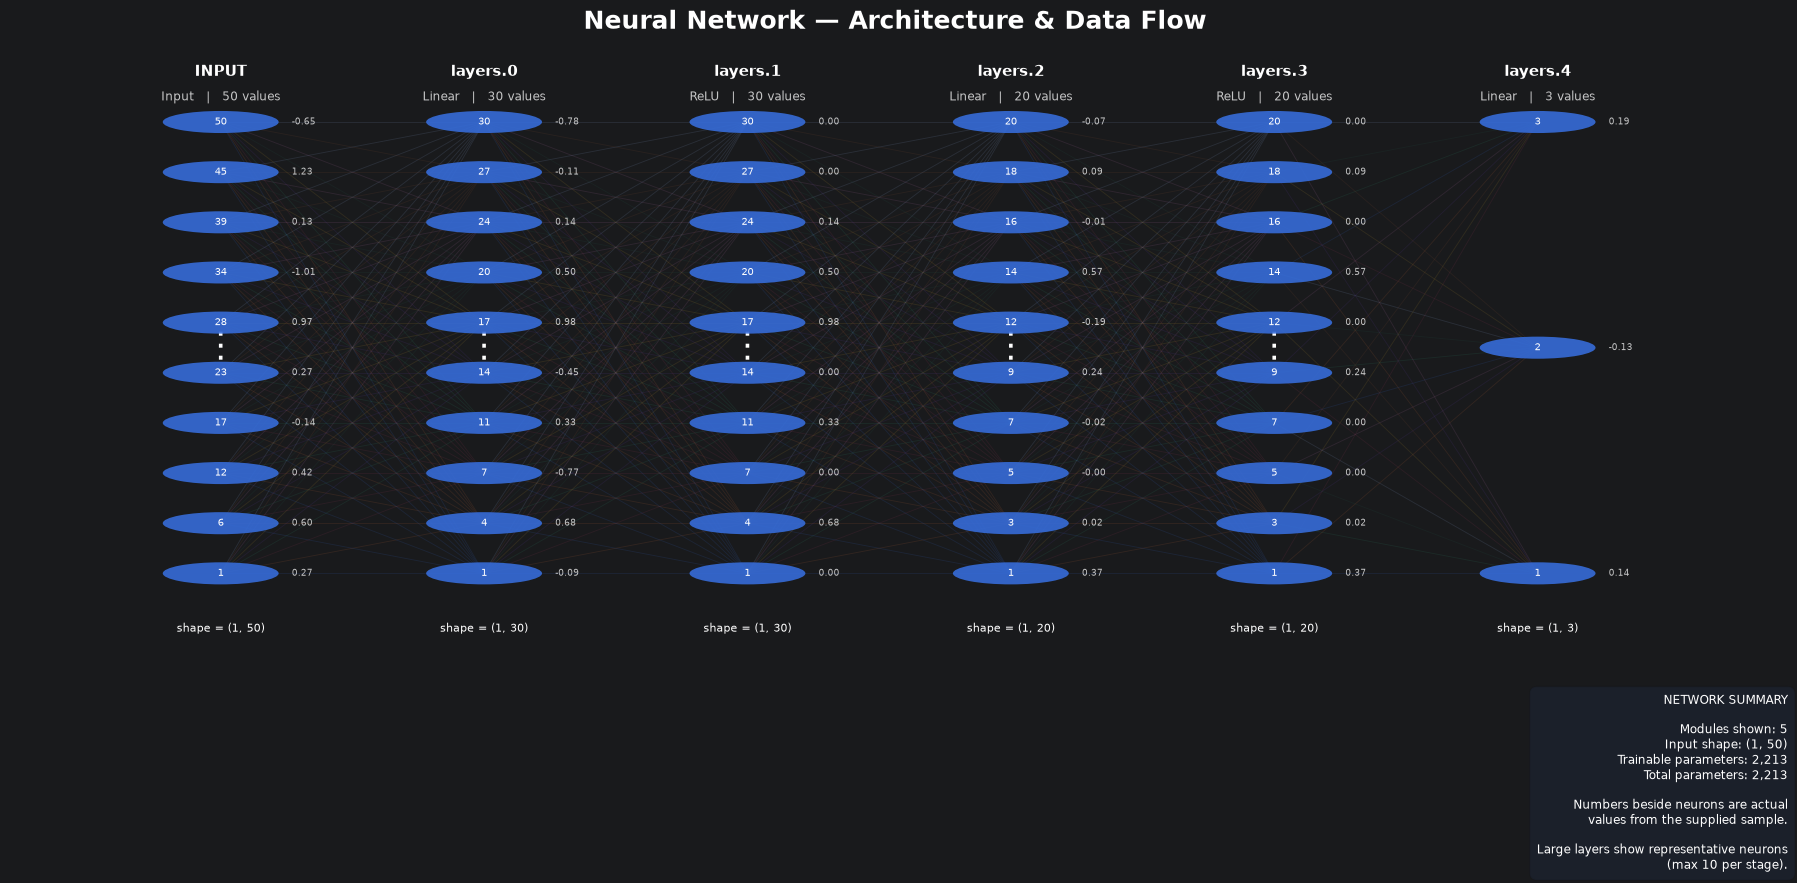

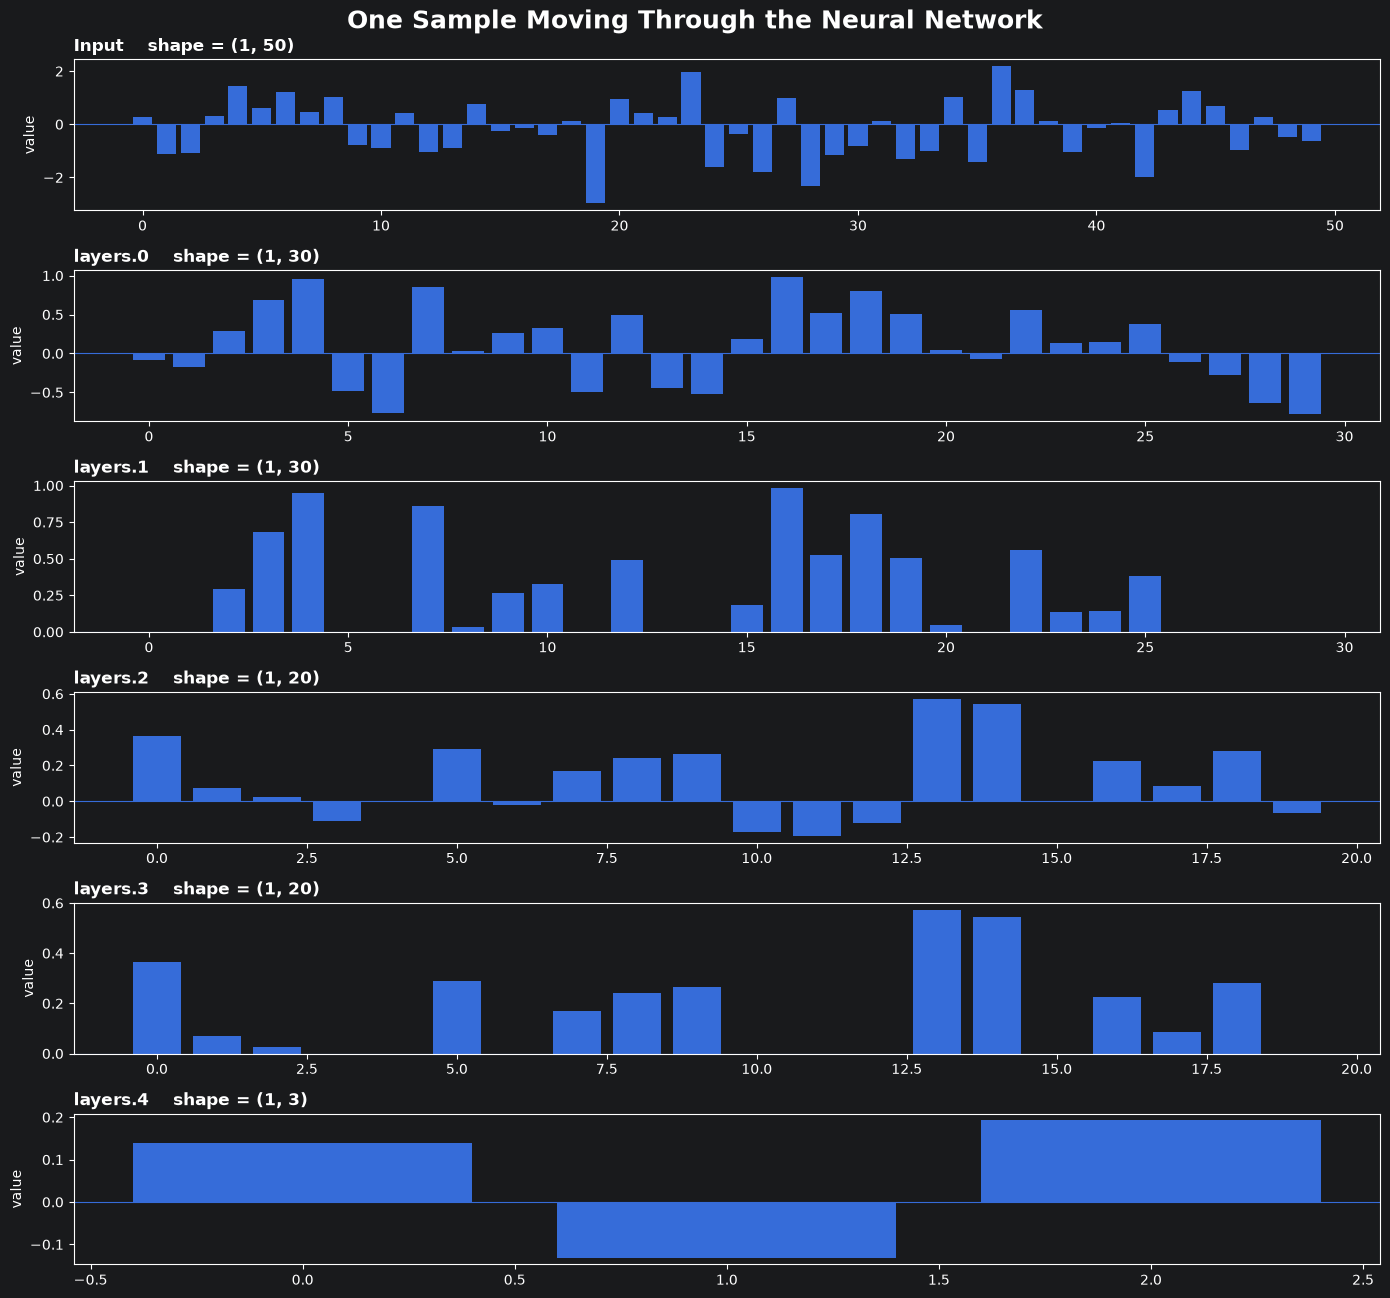

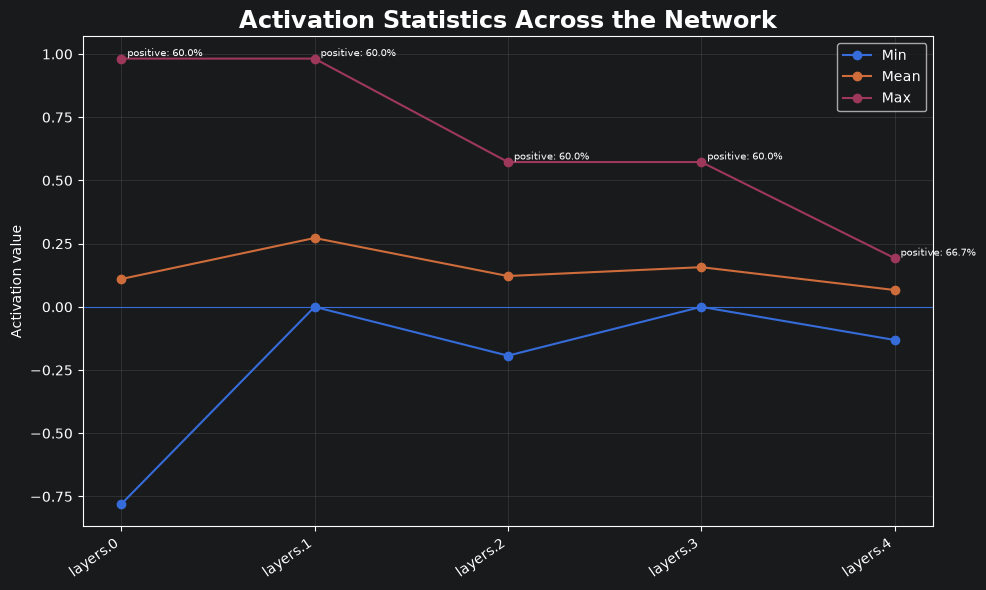

{'summary': {'model_type': 'NeuralNetwork',
  'training': True,
  'parameters': {'trainable': 2213, 'total': 2213},
  'modules': [{'name': 'layers.0',
    'type': 'Linear',
    'parameters': 1530,
    'in_features': 50,
    'out_features': 30,
    'weight_shape': (30, 50),
    'bias_shape': (30,)},
   {'name': 'layers.1', 'type': 'ReLU', 'parameters': 0},
   {'name': 'layers.2',
    'type': 'Linear',
    'parameters': 620,
    'in_features': 30,
    'out_features': 20,
    'weight_shape': (20, 30),
    'bias_shape': (20,)},
   {'name': 'layers.3', 'type': 'ReLU', 'parameters': 0},
   {'name': 'layers.4',
    'type': 'Linear',
    'parameters': 63,
    'in_features': 20,
    'out_features': 3,
    'weight_shape': (3, 20),
    'bias_shape': (3,)}],
  'input': {'shape': (1, 50), 'dtype': 'torch.float32', 'device': 'cpu'}},
 'final_output': tensor([[ 0.1382, -0.1310,  0.1926]]),
 'traces': [TraceEntry(name='layers.0', module=Linear(in_features=50, out_features=30, bias=True), input=tensor(

In [5]:
# from nn_visualization_legacy import visualize_network
# visualize_network(model, X)

from nn_visualization_old import visualize_nn
visualize_nn(model, X)

NEURAL NETWORK SUMMARY
Model:              NeuralNetwork
Trainable params:   2,213
Total params:       2,213
Input shape:        (1, 50)
Input dtype:        torch.float32
Input device:       cpu

MODULES
------------------------------------------------------------------------------
 0. layers.0: Linear (1,530 params)
     50 → 30 | weight=(30, 50) | bias=(30,)
 1. layers.1: ReLU (0 params)
 2. layers.2: Linear (620 params)
     30 → 20 | weight=(20, 30) | bias=(20,)
 3. layers.3: ReLU (0 params)
 4. layers.4: Linear (63 params)
     20 → 3 | weight=(3, 20) | bias=(3,)


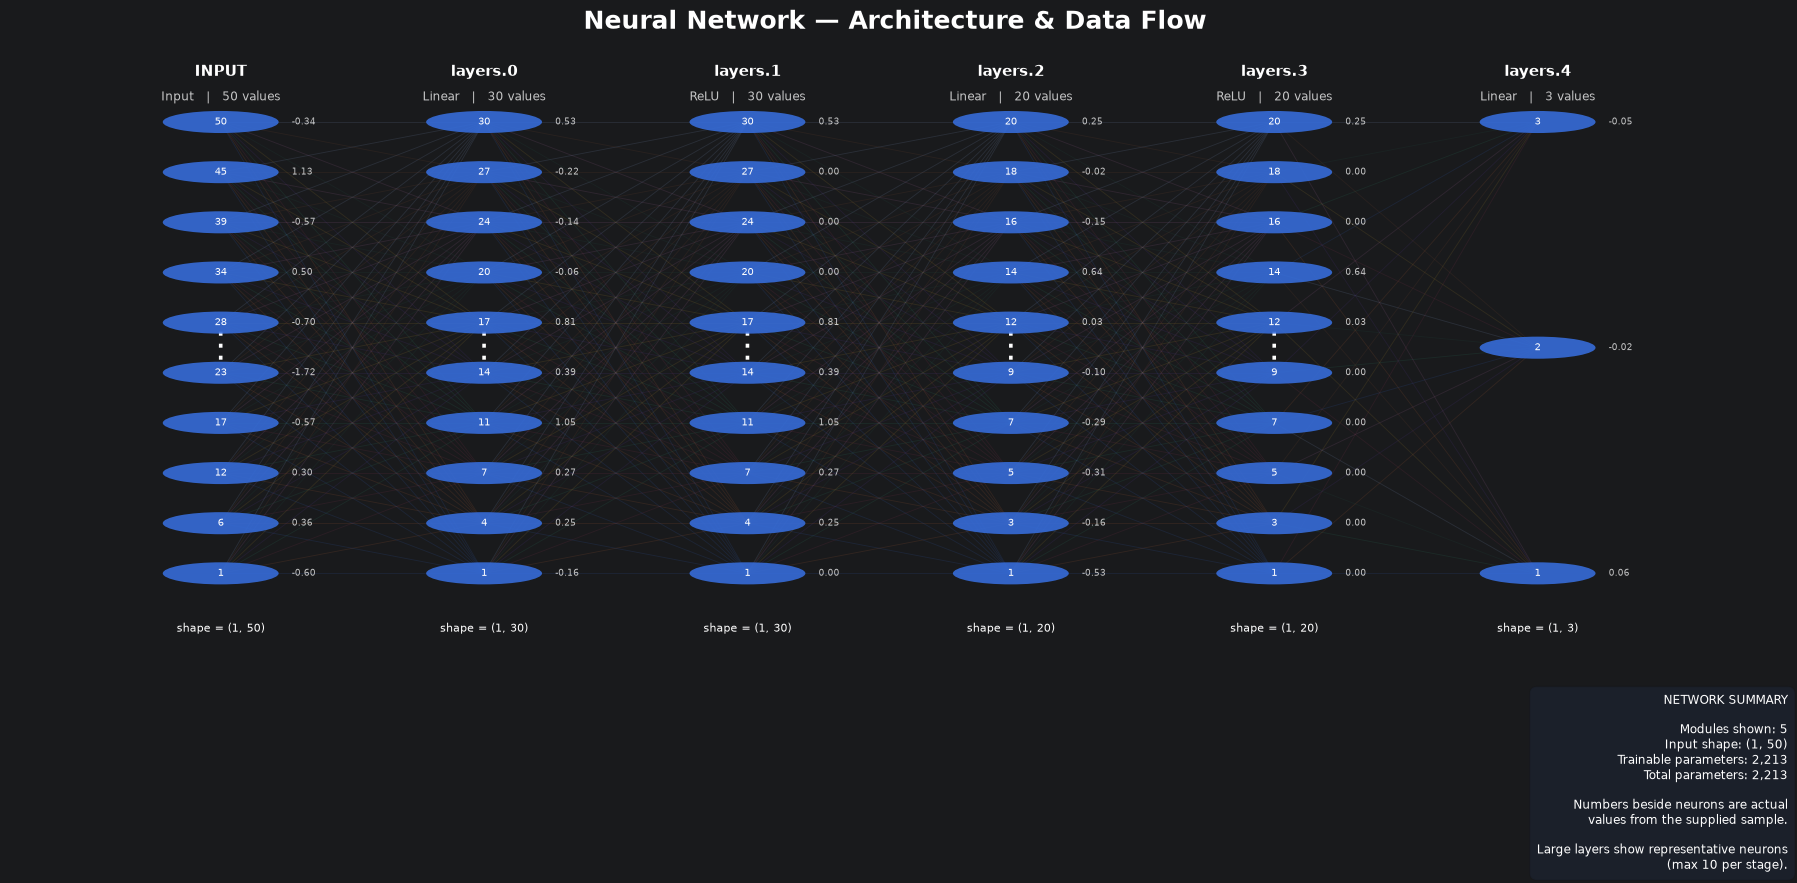

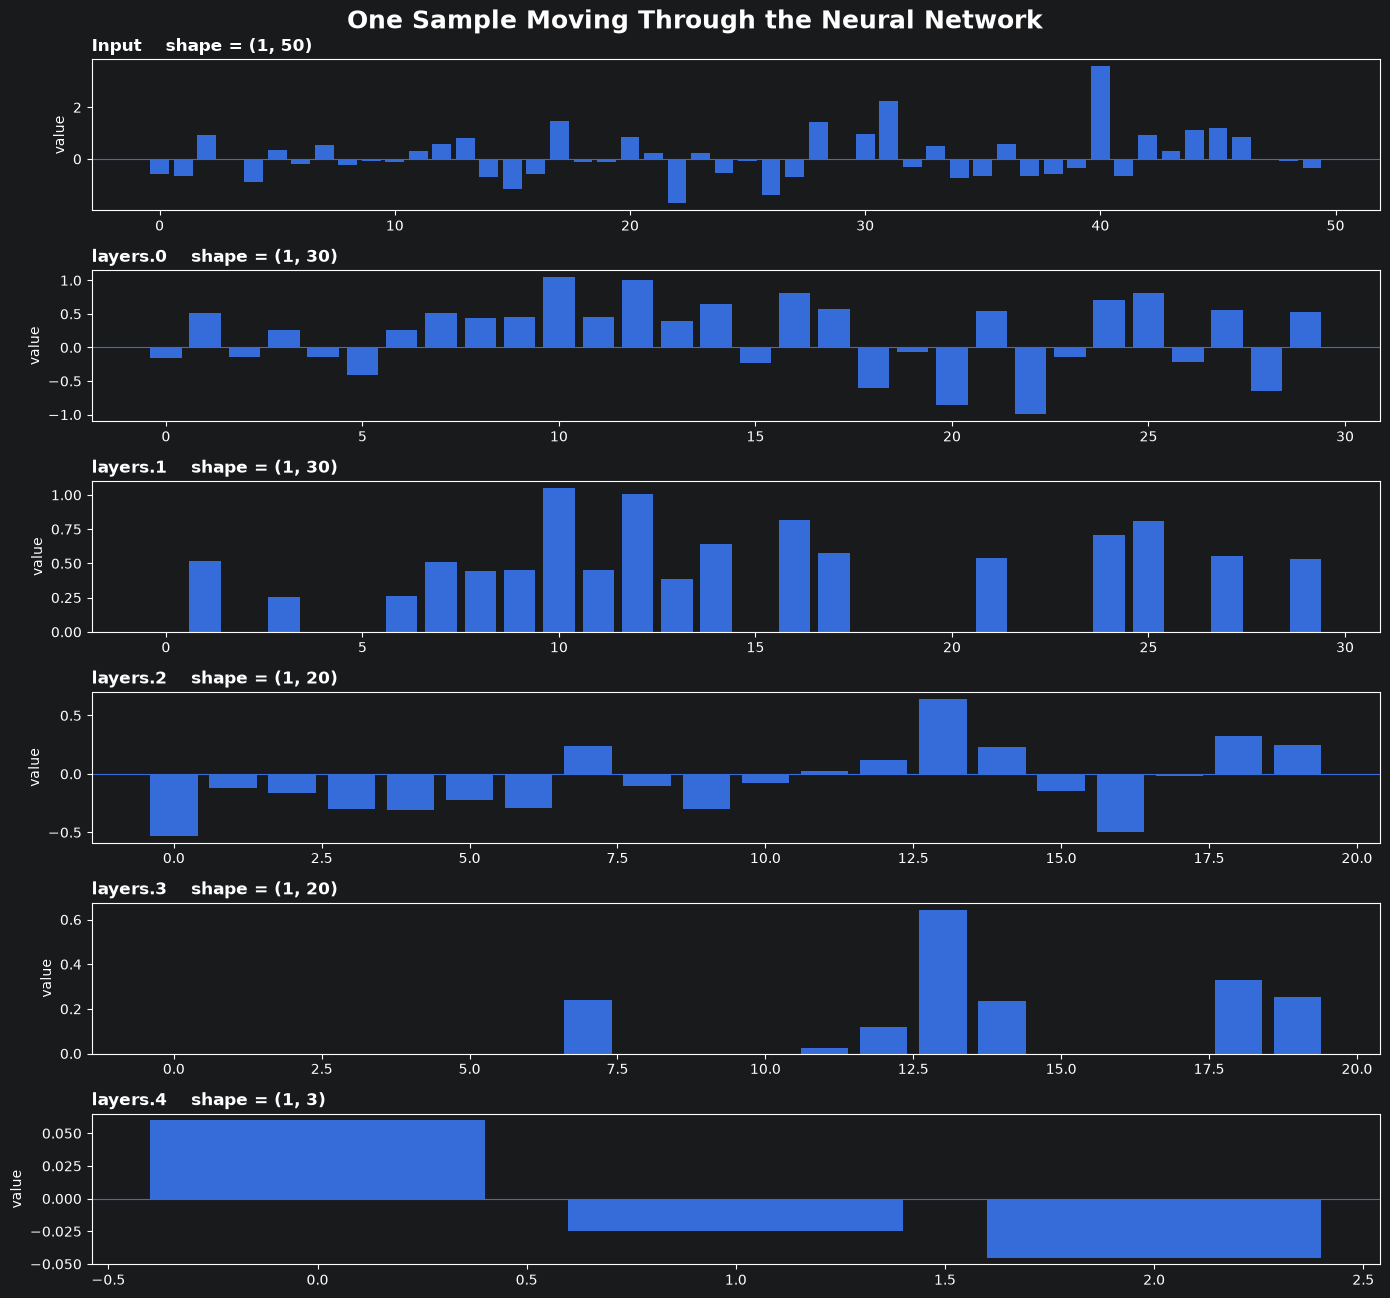

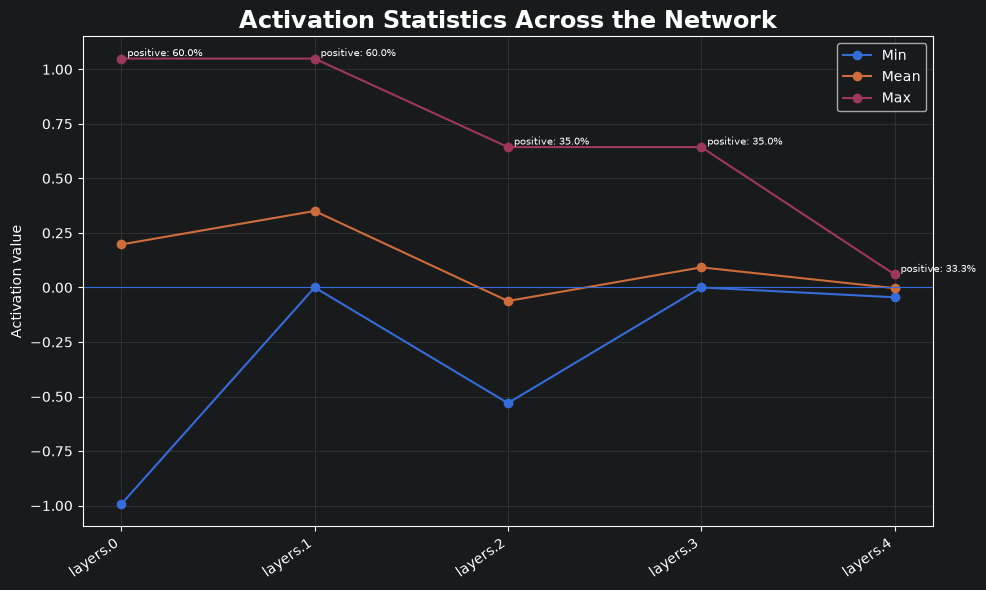


### Assets

Generated assets are saved under:

`D:\workspace\AI\GenAI\llm-from-scratch\notebooks\assets\nn_visualizations`

The returned dictionary also contains the exact generated file paths in:

`result["assets"]`


{'summary': {'model_type': 'NeuralNetwork',
  'training': True,
  'parameters': {'trainable': 2213, 'total': 2213},
  'modules': [{'name': 'layers.0',
    'type': 'Linear',
    'parameters': 1530,
    'in_features': 50,
    'out_features': 30,
    'weight_shape': (30, 50),
    'bias_shape': (30,)},
   {'name': 'layers.1', 'type': 'ReLU', 'parameters': 0},
   {'name': 'layers.2',
    'type': 'Linear',
    'parameters': 620,
    'in_features': 30,
    'out_features': 20,
    'weight_shape': (20, 30),
    'bias_shape': (20,)},
   {'name': 'layers.3', 'type': 'ReLU', 'parameters': 0},
   {'name': 'layers.4',
    'type': 'Linear',
    'parameters': 63,
    'in_features': 20,
    'out_features': 3,
    'weight_shape': (3, 20),
    'bias_shape': (3,)}],
  'input': {'shape': (1, 50), 'dtype': 'torch.float32', 'device': 'cpu'}},
 'final_output': tensor([[ 0.0599, -0.0244, -0.0451]]),
 'traces': [TraceEntry(name='layers.0', module=Linear(in_features=50, out_features=30, bias=True), input=tensor(

In [7]:
from nn_visualization import visualize_nn

# visualize_nn(model, X, debug=True, animation=True, save=True)
visualize_nn(model, X, save=True)

In [6]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


In the case of our neural network model with the preceding two hidden layers,
these trainable parameters are contained in the torch.nn.Linear layers. A Linear
layer multiplies the inputs with a weight matrix and adds a bias vector. This is some
times referred to as a feedforward or fully connected layer.

Based on the print(model) call we executed here, we can see that the first Linear
layer is at index position 0 in the layers attribute. We can access the corresponding
weight parameter matrix as follows:

In [9]:
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0605,  0.0198,  0.1340,  ..., -0.0746, -0.0201, -0.0010],
        [ 0.1206,  0.0859,  0.0593,  ...,  0.0397, -0.1314,  0.0595],
        [-0.0378,  0.0287, -0.0518,  ...,  0.1313, -0.0973, -0.0346],
        ...,
        [-0.0625, -0.0523,  0.0557,  ...,  0.0796, -0.1337,  0.1165],
        [ 0.0894, -0.0820, -0.1266,  ...,  0.1380,  0.1105,  0.0961],
        [ 0.0487,  0.0446,  0.0968,  ...,  0.0782, -0.0643,  0.1288]],
       requires_grad=True)


In [10]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


The weight matrix here is a 30 × 50 matrix, and we can see that requires_grad is
set to True, which means its entries are trainable—this is the default setting for
weights and biases in torch.nn.Linear.

In [11]:
torch.manual_seed(123)
model = NeuralNetwork(50, 3)
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


In [12]:
torch.manual_seed(123)
X = torch.rand((1, 50))
out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


In the preceding code, we generated a single random training example X as a toy
input (note that our network expects 50-dimensional feature vectors) and fed it to the
model, returning three scores. When we call model(x), it will automatically execute
the forward pass of the model.

The forward pass refers to calculating output tensors from input tensors. This
involves passing the input data through all the neural network layers, starting from
the input layer, through hidden layers, and finally to the output layer.

These three numbers returned here correspond to a score assigned to each of the
three output nodes. Notice that the output tensor also includes a grad_fn value

Here, grad_fn=<AddmmBackward0> represents the last-used function to compute a
variable in the computational graph. In particular, grad_fn=<AddmmBackward0> means
that the tensor we are inspecting was created via a matrix multiplication and addition
operation. PyTorch will use this information when it computes gradients during back
propagation. The <AddmmBackward0> part of grad_fn=<AddmmBackward0> specifies the
operation performed. In this case, it is an Addmm operation. Addmm stands for matrix
multiplication (mm) followed by an addition (Add).

when we use a model for inference (for instance, making
predictions) rather than training, the best practice is to use the torch.no_grad() con
text manager. This tells PyTorch that it doesn’t need to keep track of the gradients,
which can result in significant savings in memory and computation

In [13]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


In PyTorch, it’s common practice to code models such that they return the outputs of
the last layer (logits) without passing them to a nonlinear activation function. That’s
because PyTorch’s commonly used loss functions combine the softmax (or sigmoid
for binary classification) operation with the negative log-likelihood loss in a single
class. The reason for this is numerical efficiency and stability. So, if we want to com
pute class-membership probabilities for our predictions, we have to call the softmax
function explicitly:

In [14]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)

tensor([[0.3113, 0.3934, 0.2952]])


The values can now be interpreted as class-membership probabilities that sum up to 1.
The values are roughly equal for this random input, which is expected for a randomly
initialized model without training.


### Data Loaders

In [11]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
y_train = torch.tensor([0, 0, 0, 1, 1])


In [12]:
X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6]
])
y_test = torch.tensor([0, 1])

In [16]:
from torch.utils.data import Dataset, DataLoader

In [10]:
class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]

In [13]:
train_ds = ToyDataset(X_train, y_train)

In [14]:
test_ds = ToyDataset(X_test, y_test)

In [15]:
print(len(train_ds))

5


In [17]:
torch.manual_seed(123)

In [18]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

In [19]:
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [20]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}", x, y)

Batch 1 tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2 tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3 tensor([[ 2.7000, -1.5000]]) tensor([1])


As we can see based on the preceding output, the train_loader iterates over the train
ing dataset, visiting each training example exactly once. This is known as a _training
epoch._

Since we seeded the random number generator using torch.manual_seed(123)
here, you should get the exact same shuffling order of training examples. However, if
you iterate over the dataset a second time, you will see that the shuffling order will
change. This is desired to prevent deep neural networks from getting caught in repet
itive update cycles during training.

In [21]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

In [22]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}", x, y)

Batch 1 tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 2 tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])


### Training Loop

In [23]:
import torch.nn.functional as F

In [24]:
torch.manual_seed(123)

model = NeuralNetwork(num_inputs=2, num_outputs=2)

In [25]:
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.5
)

In [26]:
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        logits = model(features)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Train Loss: {loss:.2f}")
    model.eval()

Epoch: 001/003 | Batch 000/002 | Train Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train Loss: 0.00


In [27]:
model.eval()
with torch.no_grad():
    outputs = model(X_train)
print(outputs)

tensor([[ 2.8569, -4.1618],
        [ 2.5382, -3.7548],
        [ 2.0944, -3.1820],
        [-1.4814,  1.4816],
        [-1.7176,  1.7342]])


In [28]:
torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs, dim=1)
print(probas)

tensor([[0.9991, 0.0009],
        [0.9982, 0.0018],
        [0.9949, 0.0051],
        [0.0491, 0.9509],
        [0.0307, 0.9693]])


Let’s consider the first row in the preceding code output. Here, the first value (col
umn) means that the training example has a 99.91% probability of belonging to class
0 and a 0.09% probability of belonging to class 1. (The set_printoptions call is used
here to make the outputs more legible.)

In [29]:
predictions = torch.argmax(probas, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [30]:
predictions = torch.argmax(outputs, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [31]:
predictions == y_train

tensor([True, True, True, True, True])

In [32]:
torch.sum(predictions == y_train)

tensor(5)

In [33]:
def compute_accuracy(model, dataloader):
    model = model.eval()
    correct = 0.0
    total_examples = 0
    for idx, (features, labels) in enumerate(dataloader):
        with torch.no_grad():
            logits = model(features)
        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)
    return (correct / total_examples).item()

In [34]:
print(compute_accuracy(model, train_loader))

1.0


In [35]:
print(compute_accuracy(model, test_loader))

1.0
